In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import pandas
import geopandas
import xarray
import sparse
import xvec
from datetime import datetime, timedelta
import openeo
import io
import pystac_client
import matplotlib.pyplot as plt

In [2]:
# Platform configuration
ISO_8601 = '%Y-%m-%dT%H:%M:%SZ'

# STAC service URL
#STAC_URL="https://stac-fastapi-pgstac-nasageospatial-dev.cash.sl.cloud9.ibm.com" # Dev instance
STAC_URL="https://stac-fastapi-pgstac-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com" # Staging

# OpenEO service URL
#OPENEO_URL="https://tensorlakehouse-openeo-driver-nasageospatial-dev.cash.sl.cloud9.ibm.com" # Dev instance
OPENEO_URL="https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com" # Staging

# authenticate_oidc_resource_owner_password_credentials for OPENEO_URL="https://tensorlakehouse-openeo-driver-nasageospatial-dev.cash.sl.cloud9.ibm.com"
APPID_USERNAME = os.environ["APPID_USERNAME"]
APPID_PASSWORD = os.environ["APPID_PASSWORD"]
OPENEO_AUTH_CLIENT_ID = os.environ["OPENEO_AUTH_CLIENT_ID"]
OPENEO_AUTH_CLIENT_SECRET = os.environ["OPENEO_AUTH_CLIENT_SECRET"]

print(f"OPENEO_URL: {OPENEO_URL}")
print(f"STAC_URL:   {STAC_URL}")

OPENEO_URL: https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com
STAC_URL:   https://stac-fastapi-pgstac-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com


In [3]:
%%time
# OpenEO Connection
connection = openeo.connect(OPENEO_URL)
connection

CPU times: total: 0 ns
Wall time: 612 ms


<Connection to 'https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com/openeo/1.2/' with NullAuth>

In [4]:
%%time
# OpenEO Authentication
connection.authenticate_oidc_resource_owner_password_credentials(
    username=APPID_USERNAME,
    password=APPID_PASSWORD,
    client_id=OPENEO_AUTH_CLIENT_ID,
    client_secret=OPENEO_AUTH_CLIENT_SECRET,
    provider_id="app_id",
    store_refresh_token=False,
)
connection

CPU times: total: 0 ns
Wall time: 884 ms


<Connection to 'https://tensorlakehouse-openeo-driver-geospatial-be-staging.apps.fmaas-backend.fmaas.res.ibm.com/openeo/1.2/' with OidcBearerAuth>

In [5]:
# STAC catalogue
catalog = pystac_client.Client.open(STAC_URL)
collections = catalog.get_all_collections()
cl_id = [c.id for c in collections]
for c in cl_id:
    print(f"collection: {c}")

collection: esa-sentinel-2A-msil1c
collection: HLSS30
collection: global-weather-era5
collection: test-tasmax-rcp85-land-cpm-uk-2.2km
collection: gedi-l2a
collection: atmospheric-era5
collection: test-gedi-l2a
collection: atmospheric-weather-era5
collection: ds335-sentinel1
collection: sentinel-1-grd
collection: ibm-eis-ga-1-esa-sentinel-2-l2a
collection: Radar
collection: Radar-10min
collection: tasmax-rcp85-land-cpm-uk-2.2km
collection: ibm-eis-ga-1-era5-pr-wdc
collection: HLSL30_version2
collection: vector-osm-power
collection: vector-osm-building
collection: vector-osm-road
collection: vector-osm-natural
collection: vector-osm-railway
collection: vector-osm-boundary
collection: vector-osm-landuse
collection: vector-osm-waterway
collection: dev-hsi-radar-10min
collection: vector-kaggle-wildfire
collection: vector-ne-10m-admin0-countries
collection: vector-oil-gas-infrastructure-mapping
collection: vector-ne-10m-admin1-states_provinces
collection: vector-ne-10m-admin2-counties
collec

In [6]:
# Query Parameters

# OpenEO notation
#spatial_extent={"west": -73.96, "south": 41.12, "east": -73.9, "north": 41.18}  # Rockland Lake
spatial_extent={"west": 2.26, "south": 48.84, "east": 2.32, "north": 48.90}  # Paris arc de triomphe

# Temporal
#year = 2023
dt_start = datetime(1970, 1, 1)
start = dt_start.strftime(ISO_8601)
dt_end = datetime(2030, 1, 1)-timedelta(seconds=1)
end = dt_end.strftime(ISO_8601)
# STAC notation
time_range = f"{start}/{end}"
# OpenEO notation
temporal_extent = [start, end]

# Vectordata output format
output_format = "Parquet"

print(f"time_range:     {time_range}")
print(f"output_format:  {output_format}")

time_range:     1970-01-01T00:00:00Z/2029-12-31T23:59:59Z
output_format:  Parquet


In [7]:
# Collection: method "describe_collection" shows description and available bands/timestamps
collection_id = "vector-osm-road"
collection = catalog.get_collection(collection_id)
cube_dimensions = collection.extra_fields['cube:dimensions']
bands = cube_dimensions['bands']['values']
dt_cols = [key for key in cube_dimensions if cube_dimensions[key]['type']=="temporal"]
geom_cols = [key for key in cube_dimensions if cube_dimensions[key]['type']=="geometry"]
id_cols = []
dims = id_cols + geom_cols + dt_cols
connection.describe_collection(collection_id)

{'cube:dimensions': {'bands': {'type': 'bands',
   'values': ['address',
    'admin_level',
    'aerialway',
    'aeroway',
    'amenity',
    'barrier',
    'boundary',
    'building',
    'craft',
    'emergency',
    'geological',
    'highway',
    'historic',
    'is_in',
    'land_area',
    'landuse',
    'leisure',
    'man_made',
    'military',
    'name',
    'name:en',
    'natural',
    'office',
    'osm_id',
    'osm_node_id',
    'osm_relation_id',
    'osm_version',
    'osm_way_id',
    'other_tags',
    'place',
    'power',
    'public_transport',
    'pyogrio_layer',
    'railway',
    'ref',
    'route',
    'shop',
    'sport',
    'tourism',
    'type',
    'waterway',
    'z_order']},
  'osm_timestamp': {'extent': ['2006-03-22T20:54:52+00:00',
    '2024-05-19T23:59:51+00:00'],
   'type': 'temporal'}},
 'deprecated': False,
 'description': 'Open Street Map (OSM) Road network (non-nan "highway" key).',
 'extent': {'spatial': {'bbox': [[-180,
     -90,
     179.9999999999999,
     89.9999999999999]]},
  'temporal': {'interval': [['2006-03-22T20:54:52Z',
     '2024-05-19T23:59:51Z']]}},
 'id': 'vector-osm-road',
 'keywords': [],
 'license': 'Unknown',
 'links': [{'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-road/items',
   'rel': 'items',
   'type': 'application/geo+json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'parent',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/',
   'rel': 'root',
   'title': 'stac-fastapi',
   'type': 'application/json'},
  {'href': 'http://stac-fastapi-pgstac.geospatial-be-staging.svc.cluster.local:8080/collections/vector-osm-road',
   'rel': 'self',
   'type': 'application/json'}],
 'providers': [{'description': 'Producers of awesome spatiotemporal assets',
   'name': 'IBM',
   'roles': ['producer', 'processor'],
   'url': 'https://www.ibm.com'}],
 'stac_extensions': ['https://stac-extensions.github.io/datacube/v2.2.0/schema.json'],
 'stac_version': '1.0.0',
 'summaries': {},
 'title': 'OSM Road',
 'type': 'Collection',
 'version': ''}

In [8]:
%%time
# Compute and Stream to GeoPandas
query_bands = bands
print("query_bands:", query_bands)

datacube: openeo.DataCube = connection.load_collection(
    collection_id=collection_id,
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=query_bands,
)
datacube = datacube.save_result(format=output_format)

gdf = geopandas.read_parquet(io.BytesIO(datacube.download())).reset_index(drop=True)
gdf.dropna(axis=1).tail(2)

query_bands: ['address', 'admin_level', 'aerialway', 'aeroway', 'amenity', 'barrier', 'boundary', 'building', 'craft', 'emergency', 'geological', 'highway', 'historic', 'is_in', 'land_area', 'landuse', 'leisure', 'man_made', 'military', 'name', 'name:en', 'natural', 'office', 'osm_id', 'osm_node_id', 'osm_relation_id', 'osm_version', 'osm_way_id', 'other_tags', 'place', 'power', 'public_transport', 'pyogrio_layer', 'railway', 'ref', 'route', 'shop', 'sport', 'tourism', 'type', 'waterway', 'z_order']


Preflight process graph validation raised: [Internal] 'TensorLakehouseProcessRegistry' object has no attribute 'get_function'


CPU times: total: 203 ms
Wall time: 10.1 s


,pyogrio_layer,osm_timestamp,other_tags,osm_id,osm_version,geometry,highway
40221,points,2021-12-19 19:07:33+00:00,"{""crossing"": ""uncontrolled"", ""crossing:island""...",n6052944785,6,POINT (2.31917 48.89982),crossing
40222,lines,2021-09-15 01:30:31+00:00,"{""cycleway"": ""no"", ""lit"": ""yes"", ""maxspeed"": ""...",r32746909,13,"LINESTRING (2.31931 48.90000, 2.31923 48.89990...",residential


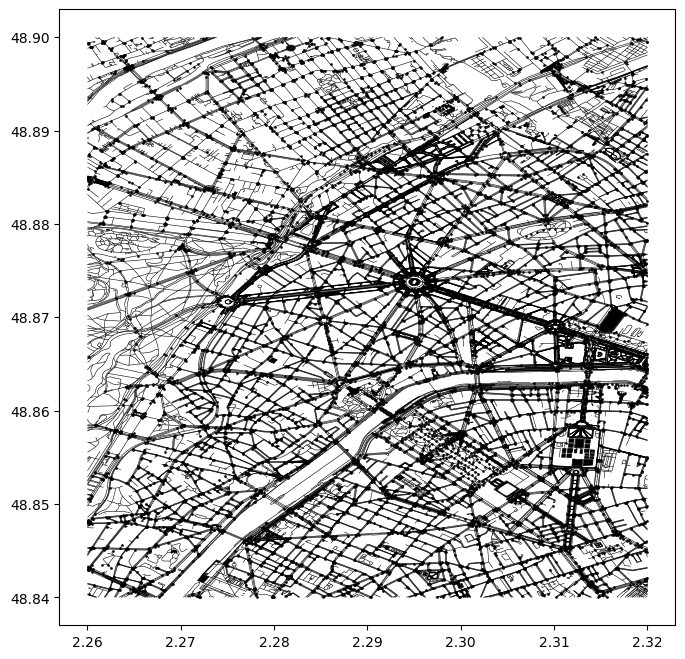

In [9]:
gdf.plot(color='k', markersize=2, edgecolor='k', lw=.4, label='entire "road" network', figsize=(8,8))
plt.show()

In [10]:
%%time 
# Cast to sparse xarray.xvec dataset
ds = xarray.Dataset.from_dataframe(
    gdf.set_index(dims),
    sparse=True,
).xvec.set_geom_indexes("geometry", crs=gdf.crs)
for dt_col in dt_cols:
    ds[dt_col] = pandas.DatetimeIndex(ds[dt_col].values)
    ds[dt_col] = pandas.DatetimeIndex(ds[dt_col].values) # Strangely we may need to do this twice
ds

CPU times: total: 656 ms
Wall time: 952 ms


Format,coo
Data Type,object
Shape,"(40223, 14928)"
nnz,40223
Density,6.69882100750268e-05
Read-only,True
Size,628.5K
Storage ratio,0.00
Format,coo
Data Type,object
Shape,"(40223, 14928)"
